# MSKCC Fitzpatrick Model - Test Set Evaluation

This notebook evaluates the trained model on the held-out test set.

**Run cells in order: 1 → 2 → 3**

In [2]:
# ==================== CELL 1: Data Preparation ====================
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import json
import os

print("Loading dataset...")
df = pd.read_csv('datasets/mskcc-skin-tone-labeling-dataset_metadata_2025-11-24.csv')
df = df.dropna(subset=['fitzpatrick_skin_type'])
print(f"✓ Loaded {len(df)} images from {df['patient_id'].nunique()} patients")

# Create patient splits (same random_state as training)
print("\nCreating patient splits...")
unique_patients = df['patient_id'].unique()
train_patients, temp_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)
val_patients, test_patients = train_test_split(temp_patients, test_size=0.5, random_state=42)

print(f"✓ Splits: {len(train_patients)} train, {len(val_patients)} val, {len(test_patients)} test")

# Filter for test set only
test_df = df[df['patient_id'].isin(test_patients)].copy()
print(f"✓ Test set: {len(test_df)} images from {len(test_patients)} patients")

# Add target labels (3-way classification)
def group_fitzpatrick(skin_type):
    if skin_type in ['I', 'II']:
        return 'Light'
    elif skin_type in ['III', 'IV']:
        return 'Medium'
    else:  # V, VI
        return 'Dark'

test_df['target_label'] = test_df['fitzpatrick_skin_type'].apply(group_fitzpatrick)
print("\n✓ Class distribution in test set:")
print(test_df['target_label'].value_counts())

# Add image paths
test_df['path'] = test_df['isic_id'].apply(lambda x: f'datasets/MSKCC-images/{x}.jpg')

# Create one-hot encoded labels
label_columns = sorted(test_df['target_label'].unique())
test_df = pd.concat([test_df, pd.get_dummies(test_df['target_label'], dtype='float32')], axis=1)
test_labels = test_df[label_columns].values

print(f"\n✓ Data preparation complete!")
print(f"  Label columns: {label_columns}")
print(f"  Test labels shape: {test_labels.shape}")

Loading dataset...
✓ Loaded 4879 images from 64 patients

Creating patient splits...
✓ Splits: 51 train, 6 val, 7 test
✓ Test set: 544 images from 7 patients

✓ Class distribution in test set:
target_label
Medium    344
Dark      133
Light      67
Name: count, dtype: int64

✓ Data preparation complete!
  Label columns: ['Dark', 'Light', 'Medium']
  Test labels shape: (544, 3)


In [3]:
# ==================== CELL 2: Load Model & Build Dataset ====================
from tensorflow.keras.models import load_model

# Define focal loss (required for model loading)
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        ce = -y_true * tf.math.log(y_pred)
        focal_weight = tf.pow(1 - y_pred, gamma)
        focal_loss_val = alpha * focal_weight * ce
        return tf.reduce_sum(focal_loss_val, axis=-1)
    return loss_fn

# Load trained model
print("Loading model...")
model = load_model('outputs/best_finetuned_model.keras', 
                   custom_objects={'loss_fn': focal_loss()})
print("✓ Model loaded successfully")

# Build test dataset
IMAGE_SIZE = 260
BATCH_SIZE = 8

def parse_image(filepath, label, image_size=IMAGE_SIZE):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [image_size, image_size])
    return image, label

def build_dataset(df, label_columns, image_size, batch_size, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df[label_columns].values))
    if is_training:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(lambda x, y: parse_image(x, y, image_size), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

test_dataset = build_dataset(test_df, label_columns, IMAGE_SIZE, BATCH_SIZE, is_training=False)
print("✓ Test dataset built")

Loading model...


d:\skin cancer project\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 621 variables whereas the saved optimizer has 625 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✓ Model loaded successfully
✓ Test dataset built


Making predictions on test set...
68/68 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step

TEST SET ACCURACY: 54.78%

Detailed Classification Report:
              precision    recall  f1-score   support

        Dark       0.50      0.94      0.66       133
       Light       0.33      0.79      0.47        67
      Medium       0.88      0.35      0.50       344

    accuracy                           0.55       544
   macro avg       0.57      0.69      0.54       544
weighted avg       0.72      0.55      0.53       544



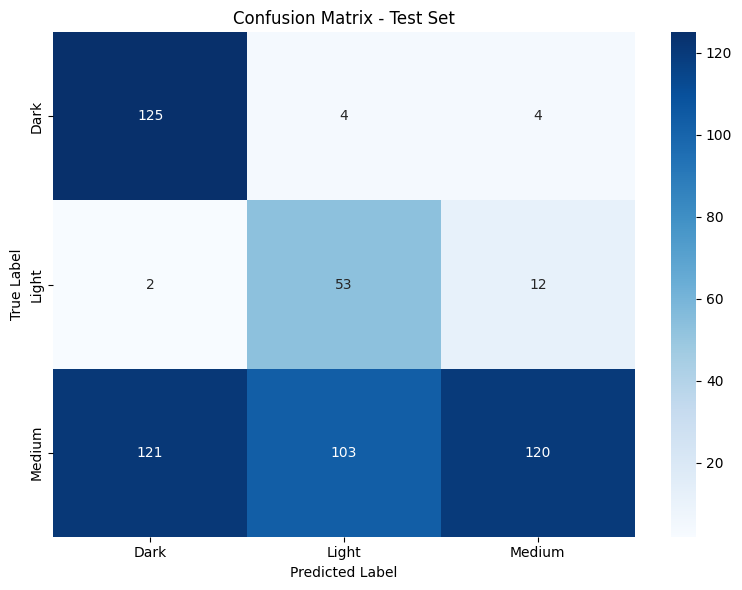


Per-Class Accuracy:
  Dark    : 93.98% (133 samples)
  Light   : 79.10% (67 samples)
  Medium  : 34.88% (344 samples)


In [4]:
# ==================== CELL 3: Predict & Evaluate ====================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions
print("Making predictions on test set...")
test_predictions = model.predict(test_dataset, verbose=1)

# Get predicted and true labels
y_true = test_labels.argmax(axis=1)
y_pred = test_predictions.argmax(axis=1)

# 1. Overall Accuracy
accuracy = (y_pred == y_true).mean()
print(f"\n{'='*60}")
print(f"TEST SET ACCURACY: {accuracy:.2%}")
print(f"{'='*60}")

# 2. Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=label_columns))

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_columns, yticklabels=label_columns)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 4. Per-Class Accuracy
print("\nPer-Class Accuracy:")
for i, label in enumerate(label_columns):
    mask = y_true == i
    class_acc = (y_pred[mask] == y_true[mask]).mean()
    count = mask.sum()
    print(f"  {label:8s}: {class_acc:.2%} ({count} samples)")

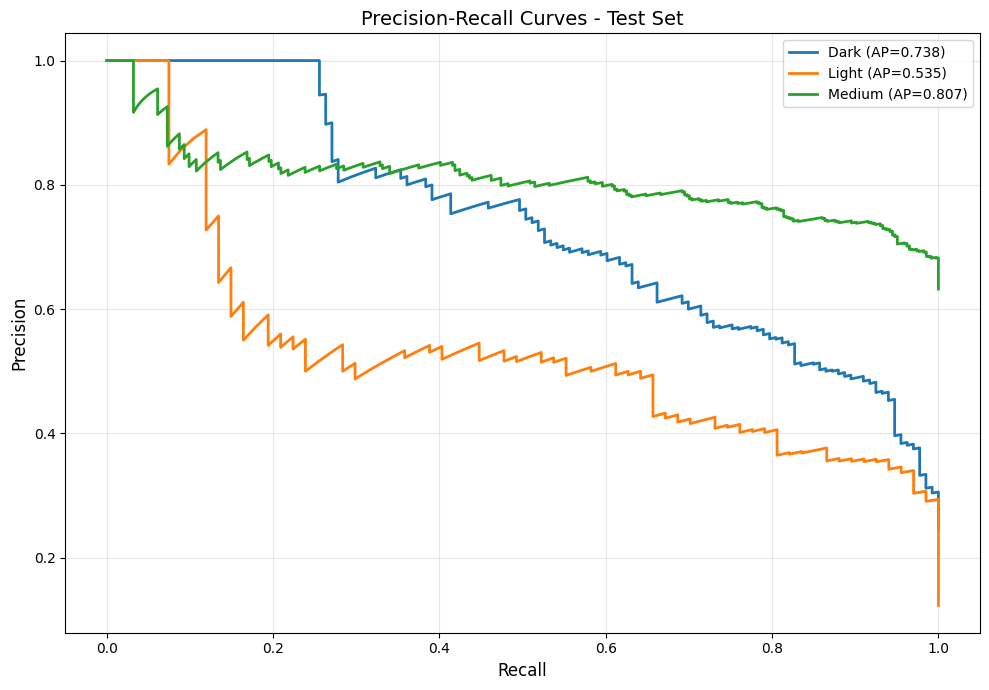

Average Precision Scores:
  Dark    : 0.738
  Light   : 0.535
  Medium  : 0.807
Total errors: 246 out of 544 (45.2%)


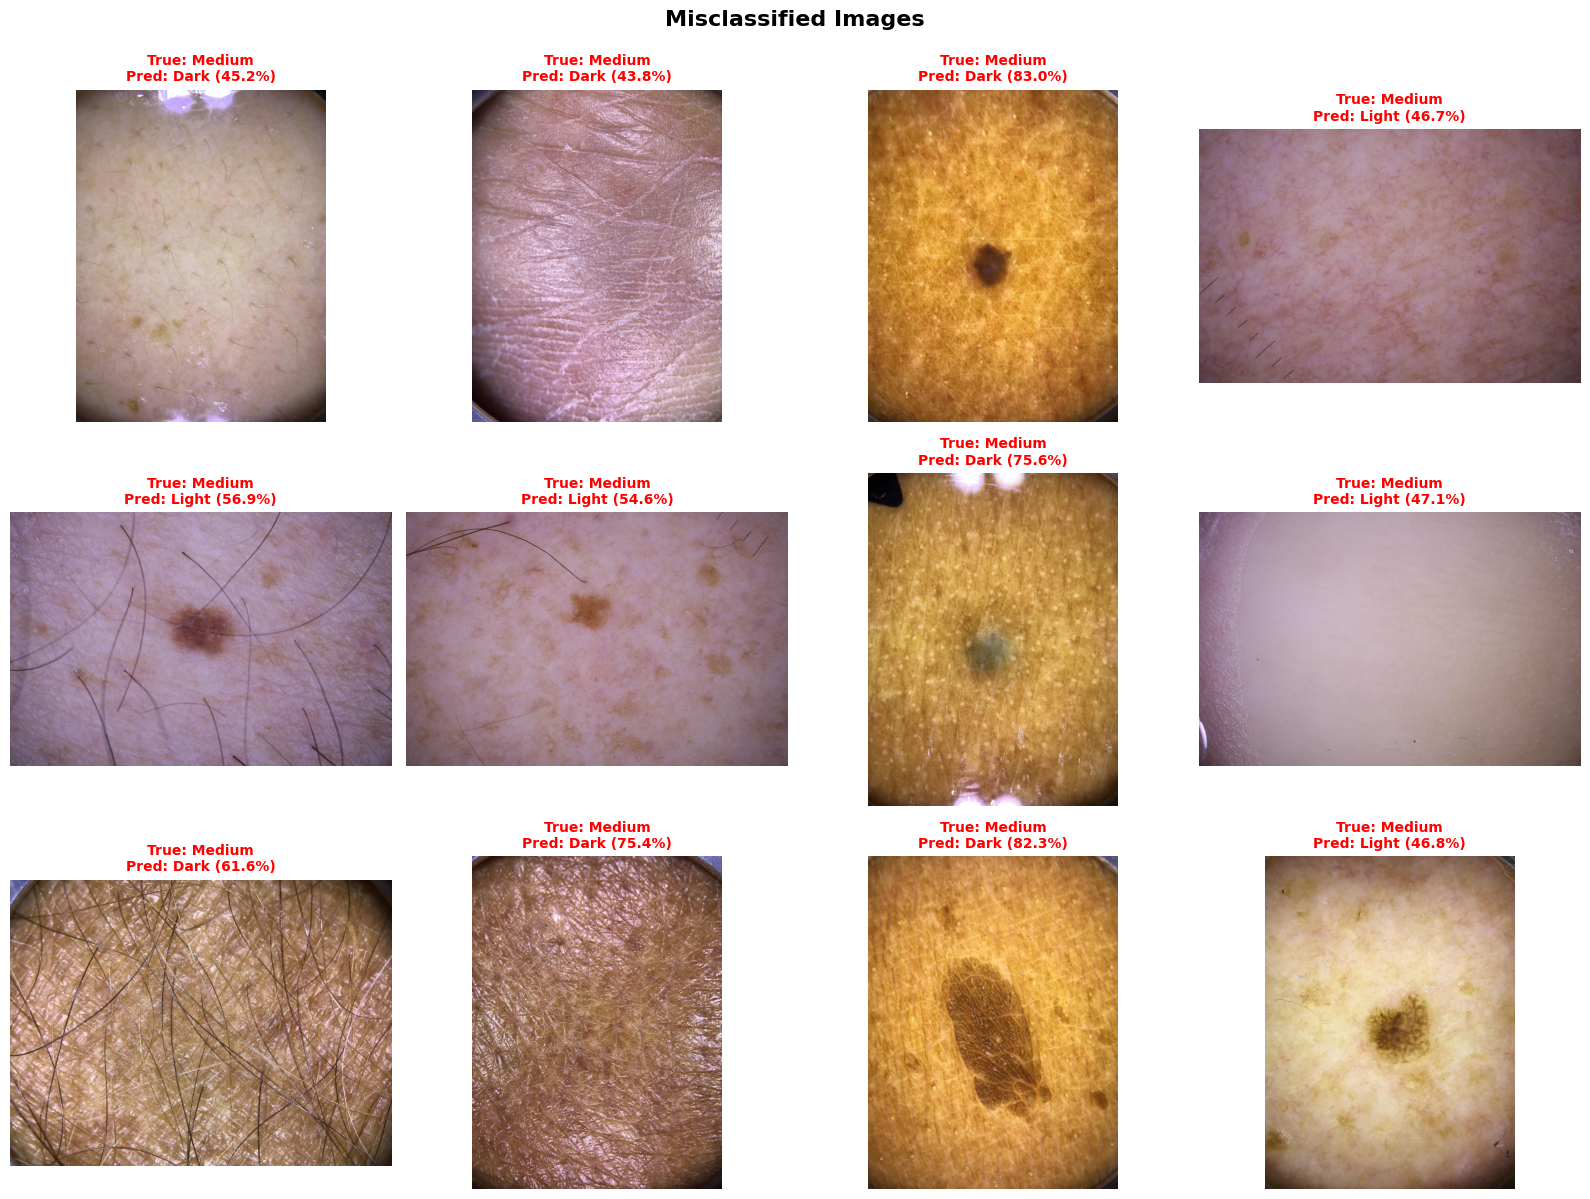


Detailed Confusion Analysis:

Dark (n=133):
  ✓ Predicted as Dark    : 125 ( 94.0%)
  ✗ Predicted as Light   :   4 (  3.0%)
  ✗ Predicted as Medium  :   4 (  3.0%)

Light (n=67):
  ✗ Predicted as Dark    :   2 (  3.0%)
  ✓ Predicted as Light   :  53 ( 79.1%)
  ✗ Predicted as Medium  :  12 ( 17.9%)

Medium (n=344):
  ✗ Predicted as Dark    : 121 ( 35.2%)
  ✗ Predicted as Light   : 103 ( 29.9%)
  ✓ Predicted as Medium  : 120 ( 34.9%)

Accuracy Breakdown by Original Fitzpatrick Type:

Type I (Light, n=67): 79.1% accuracy
  → Light   :  53 ( 79.1%)
  → Medium  :  12 ( 17.9%)
  → Dark    :   2 (  3.0%)

Type III (Medium, n=77): 57.1% accuracy
  → Medium  :  44 ( 57.1%)
  → Light   :  21 ( 27.3%)
  → Dark    :  12 ( 15.6%)

Type IV (Medium, n=267): 28.5% accuracy
  → Dark    : 109 ( 40.8%)
  → Light   :  82 ( 30.7%)
  → Medium  :  76 ( 28.5%)

Type VI (Dark, n=133): 94.0% accuracy
  → Dark    : 125 ( 94.0%)
  → Medium  :   4 (  3.0%)
  → Light   :   4 (  3.0%)



In [5]:
# ==================== CELL 5: Precision-Recall Curves ====================
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7))

for i, label in enumerate(label_columns):
    precision, recall, _ = precision_recall_curve(
        test_labels[:, i], 
        test_predictions[:, i]
    )
    ap = average_precision_score(test_labels[:, i], test_predictions[:, i])
    ax.plot(recall, precision, lw=2, label=f'{label} (AP={ap:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Test Set', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Average Precision Scores:")
for i, label in enumerate(label_columns):
    ap = average_precision_score(test_labels[:, i], test_predictions[:, i])
    print(f"  {label:8s}: {ap:.3f}")


# ==================== CELL 6: Error Analysis with Images ====================
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Find misclassified samples
y_true = test_labels.argmax(axis=1)
y_pred = test_predictions.argmax(axis=1)
errors = y_true != y_pred
error_indices = np.where(errors)[0]

print(f"Total errors: {len(error_indices)} out of {len(test_df)} ({len(error_indices)/len(test_df):.1%})")

# Show first 12 misclassified images
n_to_show = min(12, len(error_indices))
if n_to_show > 0:
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, error_idx in enumerate(error_indices[:n_to_show]):
        # Get image info
        img_path = test_df.iloc[error_idx]['path']
        true_label = label_columns[y_true[error_idx]]
        pred_label = label_columns[y_pred[error_idx]]
        confidence = test_predictions[error_idx].max()
        
        # Load and display image
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')
        
        # Add title with true/predicted labels
        title = f"True: {true_label}\nPred: {pred_label} ({confidence:.1%})"
        color = 'red'
        axes[idx].set_title(title, fontsize=10, color=color, weight='bold')
    
    # Hide unused subplots
    for idx in range(n_to_show, 12):
        axes[idx].axis('off')
    
    plt.suptitle('Misclassified Images', fontsize=16, weight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print("No errors to display - perfect classification!")


# ==================== CELL 7: Confusion Analysis per Class ====================
import pandas as pd

print("\nDetailed Confusion Analysis:\n")

for i, true_label in enumerate(label_columns):
    # Get samples for this true class
    mask = y_true == i
    true_count = mask.sum()
    
    if true_count == 0:
        continue
    
    print(f"{true_label} (n={true_count}):")
    
    # Count predictions for this true class
    for j, pred_label in enumerate(label_columns):
        pred_count = (y_pred[mask] == j).sum()
        percentage = pred_count / true_count * 100
        
        if pred_count > 0:
            symbol = "✓" if i == j else "✗"
            print(f"  {symbol} Predicted as {pred_label:8s}: {pred_count:3d} ({percentage:5.1f}%)")
    
    print()


# ==================== CELL 8: Class-wise Accuracy by Fitzpatrick Type ====================
print("Accuracy Breakdown by Original Fitzpatrick Type:\n")

# Create crosstab: rows=true Fitzpatrick type, columns=predicted 3-way label
test_df_copy = test_df.copy()
test_df_copy['predicted_label'] = [label_columns[i] for i in y_pred]
test_df_copy['correct'] = y_pred == y_true

# Group by original Fitzpatrick type
for fitz_type in sorted(test_df_copy['fitzpatrick_skin_type'].unique()):
    subset = test_df_copy[test_df_copy['fitzpatrick_skin_type'] == fitz_type]
    accuracy = subset['correct'].mean()
    count = len(subset)
    grouped = subset['target_label'].iloc[0]
    
    print(f"Type {fitz_type} ({grouped}, n={count}): {accuracy:.1%} accuracy")
    
    # Show prediction distribution
    pred_dist = subset['predicted_label'].value_counts()
    for label, cnt in pred_dist.items():
        print(f"  → {label:8s}: {cnt:3d} ({cnt/count*100:5.1f}%)")
    print()


In [6]:
# ==================== CELL 4: Verify No Data Leakage ====================
# Verify no train-test overlap
train_test_overlap = set(train_patients) & set(test_patients)
print(f"Train-Test patient overlap: {len(train_test_overlap)} (should be 0)")
assert len(train_test_overlap) == 0, "ERROR: Data leakage detected!"

print(f"\n✓ Verification passed!")
print(f"  Train patients: {len(train_patients)}")
print(f"  Val patients: {len(val_patients)}")
print(f"  Test patients: {len(test_patients)}")
print(f"  Test images: {len(test_df)}")

Train-Test patient overlap: 0 (should be 0)

✓ Verification passed!
  Train patients: 51
  Val patients: 6
  Test patients: 7
  Test images: 544
